# Code for Figure 1E

___

## Importing Libraries
___

In [1]:
# Import necessary libraries
import os
from os import listdir
from os.path import join
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import scipy.stats as stats
import seaborn as sns
from scipy.stats import mannwhitneyu

## Directories
___

In [2]:
# List of directory containing data 
current_dir = Path.cwd()
print("Current working directory:", current_dir)
data_dir = current_dir.joinpath('raw_data', 'Figure_1H')
print("Data directory:", data_dir)
plots_dir = current_dir.joinpath('plots', 'Figure_1H')
plots_dir.mkdir(parents=True, exist_ok=True)
print("Plots directory:", plots_dir)
# List all files in the data directory
files = os.listdir(data_dir)
ratio_list = [file for file in files if file.endswith('.xlsx') and 'Ratio' in file]
print(ratio_list)

Current working directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_1
Data directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_1/raw_data/Figure_1H
Plots directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_1/plots/Figure_1H
['Ratio_H2B_LE_20190418_pNZ112_mCh-H2B.xlsx', 'Ratio_H2B_LE_20190418_pNZ112_115.xlsx']


In [3]:
# Load the data from the Excel files into a dictionary of DataFrames
cells = dict()
ratio_data = []
count = 0
for file in ratio_list:
    file_path = os.path.join(data_dir, file)
    cells[count] = pd.read_excel(file_path)
    ratio_data.append(str(file_path)[-15:-5])
    count += 1

In [4]:
# Extract the ratio data from the DataFrames and create a new DataFrame
ratio_data = ['pNZ112_mCh-H2B', 'pNZ112_115']
frames = []
for i, cell in enumerate(cells.values()):
    ratio = cell.iloc[:, 0].values
    frames.append(pd.DataFrame({
        'Construct': [ratio_data[i]] * len(ratio),
        'Ratio':      ratio
    }))
df = pd.concat(frames, ignore_index=True)
df['Construct'] = df['Construct'].replace({ 'pNZ112_mCh-H2B': 'mCh-H2B',
                                            'pNZ112_115': 'Anti-Utag-FB(15F11)'})
df['Construct'] = pd.Categorical(df['Construct'], categories=['mCh-H2B', 'Anti-Utag-FB(15F11)'], ordered=True)
df = df.sort_values('Construct').reset_index(drop=True)
df 

,Construct,Ratio
0,mCh-H2B,1.017384
1,mCh-H2B,1.110468
2,mCh-H2B,1.050863
3,mCh-H2B,0.844436
4,mCh-H2B,1.028544
5,mCh-H2B,1.091080
6,mCh-H2B,1.099359
7,mCh-H2B,1.234603
8,mCh-H2B,1.001956
9,mCh-H2B,1.240996


## Plotting
____

In [5]:
def plot_box_swarm_final_values(
    df,
    selected_field,  # e.g. "Ratio"
    figsize=(6, 4),
    xlabel="Construct",
    ylabel="Final Normalized Intensity",
    title="",
    y_min=None,
    y_max=None,
    swarm_color="black",
    tick_size=16,
    show_stats=False,
):
    """
    Creates a boxplot with whiskers and an overlaid swarmplot.
    For a DataFrame with two columns:
      - "Construct": The condition (e.g. 'wtscFv', 'Anti-Utag-FB(15F11)', 'Anti-Utag-FB(2E2)')
      - selected_field (e.g. "Ratio"): The value to plot.
      
    The final value is taken directly from each row.
    
    Optionally, if display_cell_count is True, the total number of rows is displayed in the bottom right.
    If display_error is True, error bars (SEM) are overlaid on the mean values.
    
    Parameters:
    - df: pandas DataFrame that must include at least the following columns: "Construct" and the selected_field.
    - selected_field: str, the column name to plot (e.g. "Ratio").
    - figsize: tuple, figure size.
    - xlabel: str, label for the x-axis.
    - ylabel: str, label for the y-axis.
    - title: str, plot title.
    - y_min: float, minimum y-axis limit.
    - y_max: float, maximum y-axis limit.
    - swarm_color: str or color, color of the swarmplot points.
    - tick_size: int, font size for tick labels.
    - show_stats: bool, whether to show statistical comparisons.
    
    Returns:
    - ax: matplotlib Axes object containing the plot.
    """

    sns.set_style("ticks")
    # Define the desired order for the x-axis (adjust as needed)
    order_categories = ['mCh-H2B', 'Anti-Utag-FB(15F11)']
    # Use the whole DataFrame as final_df.
    final_df = df.copy()
    # Total number of data points (rows)
    # total_number = final_df.shape[0]
    # Create the figure with a white background
    for category in order_categories:
        mean_value = final_df[final_df['Construct'] == category][selected_field].mean()
        std_value = final_df[final_df['Construct'] == category][selected_field].std()
        #print(f"{category}: Mean = {mean_value:.2f}, Std Dev = {std_value:.2f}")
        n = len(final_df[final_df['Construct'] == category][selected_field])
        sem_value = std_value / (n ** 0.5)
        print(f"{category}: Mean = {mean_value:.2f}, Std Dev = {std_value:.2f}, SEM = {sem_value:.4f}, n = {n}")

    plt.figure(figsize=figsize, facecolor='white')
    ax = sns.boxplot(
        x="Construct",
        y=selected_field,
        data=final_df,
        order=order_categories,
        showfliers=True,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'red'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        linewidth=1.5,
        whis=[5, 95],  # restrict whiskers to the 5th and 95th percentiles
        width=0.5,
    )
    ax.set_facecolor('white')    
    sns.swarmplot(
        x="Construct",
        y=selected_field,
        data=final_df,
        order=order_categories,
        color=swarm_color, 
        size=5,
    )
    plt.xlabel(xlabel, fontsize=tick_size+4, fontname="Arial", color='black')
    plt.ylabel(ylabel, fontsize=tick_size+4, fontname="Arial", color='black')
    plt.title(title, fontsize=tick_size+4, fontname="Arial", color='black')
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    ax.tick_params(axis='x', labelsize=tick_size+4, colors='black')
    ax.tick_params(axis='y', labelsize=tick_size, colors='black')
    plt.xticks(fontname="Arial")
    plt.yticks(fontname="Arial")
    new_labels = ['mCh-H2B', 'Anti-Utag-FB \n (15F11)']
    ax.set_xticks(range(len(order_categories)))
    ax.set_xticklabels(new_labels, fontsize=tick_size, fontname="Arial", color='black')
    if show_stats:
        global_max = 7  
        global_min = final_df[selected_field].min()
        global_range = global_max - global_min
        offset = 0.1 * global_range  # Each comparison will be offset by this amount
        bar_height = 0.02 * global_range  # Height for the significance line
        comparisons = [((0, 1), 0)]
        for ((i, j), level) in comparisons:
            group1 = final_df[final_df['Construct'] == order_categories[i]][selected_field]
            group2 = final_df[final_df['Construct'] == order_categories[j]][selected_field]
            # Perform Mann-Whitney U test on the two groups
            stat, p = mannwhitneyu(group1, group2)
            # Determine significance annotation
            if p < 0.0001:
                sig = '****'
            elif p < 0.001:
                sig = '***'
            elif p < 0.01:
                sig = '**'
            elif p < 0.05:
                sig = '*'
            else:
                sig = 'ns'
            x1, x2 = i, j
            y_line = global_max + offset * (level + 1)
            ax.plot([x1, x1, x2, x2],
                    [y_line, y_line + bar_height, y_line + bar_height, y_line],
                    lw=1.5, c='k')
            ax.text((x1 + x2) * 0.5, y_line + bar_height, sig,
                    ha='center', va='bottom', color='k', fontsize=tick_size, fontname="Arial")
            print(f"Comparison {order_categories[i]} vs {order_categories[j]}: p-value = {p:.2e}")
    plt.tight_layout()
    # save as png and svg with a min of 600 dpi in the results dir
    plt.savefig(plots_dir / f"box_swarm_{selected_field}.png", dpi=600, bbox_inches='tight') 
    plt.savefig(plots_dir / f"box_swarm_{selected_field}.svg", dpi=600, bbox_inches='tight')
    plt.show()
    return ax

mCh-H2B: Mean = 1.10, Std Dev = 0.12, SEM = 0.0265, n = 21
Anti-Utag-FB(15F11): Mean = 2.82, Std Dev = 1.16, SEM = 0.2358, n = 24
Comparison mCh-H2B vs Anti-Utag-FB(15F11): p-value = 1.05e-08


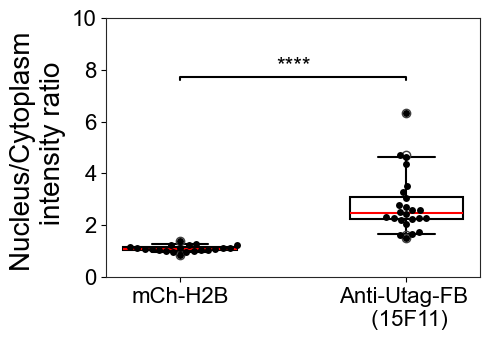

<Axes: ylabel='Nucleus/Cytoplasm \n intensity ratio'>

In [6]:
plot_box_swarm_final_values(
    df,
    selected_field='Ratio',
    figsize=(5, 3.5),
    xlabel=None,
    ylabel="Nucleus/Cytoplasm \n intensity ratio",
    title="",
    y_min=0,
    y_max=10,
    swarm_color="black",
    tick_size=16,
    show_stats=True,
)